In [ ]:
import os
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as colors
import xml.etree.ElementTree as ET

def read_aux_xml(tif_path):
    """
    Legge il file ausiliario (.tif.aux.xml) associato a tif_path e restituisce un dizionario con le statistiche.
    """
    aux_path = tif_path + ".aux.xml"
    stats = {}
    if os.path.exists(aux_path):
        try:
            tree = ET.parse(aux_path)
            root = tree.getroot()
            # Cerca i nodi <MDI> all'interno di <Metadata>
            for mdi in root.findall(".//Metadata/MDI"):
                key = mdi.get("key")
                value = mdi.text.strip() if mdi.text is not None else ""
                stats[key] = value
        except Exception as e:
            print(f"❌ Errore nella lettura di {aux_path}: {e}")
    return stats


In [ ]:
def extract_coordinates_with_data(folder_path):
    """
    Iterates over all .tif files in folder_path, extracting coordinates and corresponding valid_data values.
    Returns a dictionary where each key is a filename, and the value is a DataFrame with coordinates and data values.
    
    :param folder_path: Path to the folder containing .tif files
    :return: Dictionary {filename: DataFrame(columns=['Longitude', 'Latitude', 'Value'])}
    """
    tif_files = [f for f in os.listdir(folder_path) if f.lower().endswith('.tif')]
    if not tif_files:
        print(f"❌ No .tif files found in: {folder_path}")
        return {}
    
    tif_files.sort()
    results = {}
    
    for tif_file in tif_files:
        tif_path = os.path.join(folder_path, tif_file)
        print(f"\n📂 Processing: {tif_path}")
        
        try:
            with rasterio.open(tif_path) as src:
                data = src.read(1)  # Read first band
                transform = src.transform  # Get affine transformation
                
                # Apply NoData mask if defined
                if src.nodata is not None:
                    data = np.ma.masked_array(data, mask=(data == src.nodata))
                
                rows, cols = data.shape
                coords = []
                values = []
                
                for row in range(rows):
                    for col in range(cols):
                        if not np.ma.is_masked(data[row, col]):  # Consider only valid values
                            lon, lat = rasterio.transform.xy(transform, row, col)
                            coords.append((lon, lat))
                            values.append(data[row, col])
                
                # Create DataFrame
                df = pd.DataFrame(coords, columns=['Longitude', 'Latitude'])
                df['Value'] = values
                results[tif_file] = df
                
        except Exception as e:
            print(f"❌ Error processing {tif_file}: {e}")
    
    return results

In [ ]:
folder_path = '/Modis_Land_Cover_Data'

In [ ]:
dictionary = extract_coordinates_with_data(folder_path)

📂 Processing: /Modis_Land_Cover_Data/2010LCT.tif

📂 Processing: /Modis_Land_Cover_Data/2011LCT.tif

📂 Processing: /Modis_Land_Cover_Data/2012LCT.tif

📂 Processing: /Modis_Land_Cover_Data/2013LCT.tif

📂 Processing: /Modis_Land_Cover_Data/2014LCT.tif

📂 Processing: /Modis_Land_Cover_Data/2015LCT.tif

📂 Processing: /Modis_Land_Cover_Data/2016LCT.tif

📂 Processing: /Modis_Land_Cover_Data/2017LCT.tif

📂 Processing: /Modis_Land_Cover_Data/2018LCT.tif

📂 Processing: /Modis_Land_Cover_Data/2019LCT.tif

📂 Processing: /Modis_Land_Cover_Data/2020LCT.tif

📂 Processing: /Modis_Land_Cover_Data/2021LCT.tif

📂 Processing: /Modis_Land_Cover_Data/2022LCT.tif

📂 Processing: /Modis_Land_Cover_Data/2023LCT.tif

Let's visualize the first file 

In [ ]:
value = dictionary["2010LCT.tif"]

# Convert the value (a list of lists) into a DataFrame
dfprovaprova = pd.DataFrame(value, columns=["Longitude", "Latitude", "Value"])

In [ ]:
from pyproj import CRS, Transformer

def transform_coordinates(x, y):
    """
    Transforms coordinates from the Sinusoidal projection to WGS 84 (Latitude/Longitude).
    
    :param x: Easting (X-coordinate) in Sinusoidal projection
    :param y: Northing (Y-coordinate) in Sinusoidal projection
    :return: A tuple containing the latitude and longitude in WGS 84
    """
    # Define the Sinusoidal projection based on the PROJ4 parameters
    src_crs = CRS.from_proj4('+proj=sinu +a=6371007.181 +b=6371007.181 +units=m')

    # Define the target CRS for WGS 84 (Latitude/Longitude)
    dst_crs = CRS("EPSG:4326")  # WGS 84 (Latitude/Longitude)

    # Create a transformer object to convert between CRS
    transformer = Transformer.from_crs(src_crs, dst_crs, always_xy=True)

    # Convert the given coordinates from Sinusoidal to Latitude/Longitude
    lon, lat = transformer.transform(x, y)

    return lat, lon


In [ ]:
dfprovaprova2[['Latitude', 'Longitude']] = dfprovaprova2.apply(
    lambda row: pd.Series(transform_coordinates(row['Latitude'], row['Longitude'])), axis=1
)

When trying to transform all the 170k coordinates into the other coordinate group, it takes too much to run -> let's apply some transformations to the dataset

In [ ]:
dfprovaprova = dfprovaprova.drop(dfprovaprova.sample(n=8212, random_state=42).index)

In [ ]:
coordinates_parte2 = dfprovaprova['coordinate'].tolist()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def average_coordinates(coordinates, grid_size=20):
    """
    Averages coordinates in grid blocks (3x3).
    
    Args:
    - coordinates: List of tuples (x, y) representing coordinates.
    - grid_size: The grid size for averaging, default is 3 (for 3x3 block).
    
    Returns:
    - List of tuples containing averaged coordinates for each 3x3 block.
    """
    averaged_coords = []
    
    # We assume coordinates are sorted in the same way as a raster
    num_rows = int(np.sqrt(len(coordinates)))  # Assuming square raster (rows == cols)
    
    for row in range(0, num_rows, grid_size):
        for col in range(0, num_rows, grid_size):
            # Get the coordinates within the 3x3 block
            block_coords = []
            
            for i in range(grid_size):
                for j in range(grid_size):
                    idx = (row + i) * num_rows + (col + j)  # Index in the flat list of coordinates
                    if idx < len(coordinates):  # Ensure it's within bounds
                        block_coords.append(coordinates[idx])
            
            # Calculate the average of x and y in the block
            if block_coords:
                avg_x = np.mean([coord[0] for coord in block_coords])
                avg_y = np.mean([coord[1] for coord in block_coords])
                averaged_coords.append((avg_x, avg_y))
    
    return averaged_coords


# Step 3: Average coordinates in 3x3 blocks
averaged_coordinates_2 = average_coordinates(coordinates_parte2)

# Step 4: Plot the averaged coordinates using Matplotlib
x_coords, y_coords = zip(*averaged_coordinates_2)  # Unzip the averaged coordinates into two separate lists

# Create a scatter plot of the averaged coordinates
plt.figure(figsize=(8, 8))
plt.scatter(x_coords, y_coords, color='blue', s=1)  # s=1 sets the marker size to 1
plt.title("Averaged Coordinates Inside Each 3x3 Pixel Block")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

# Optionally, print the number of averaged coordinates
print(f"Number of averaged coordinates: {len(averaged_coordinates)}")


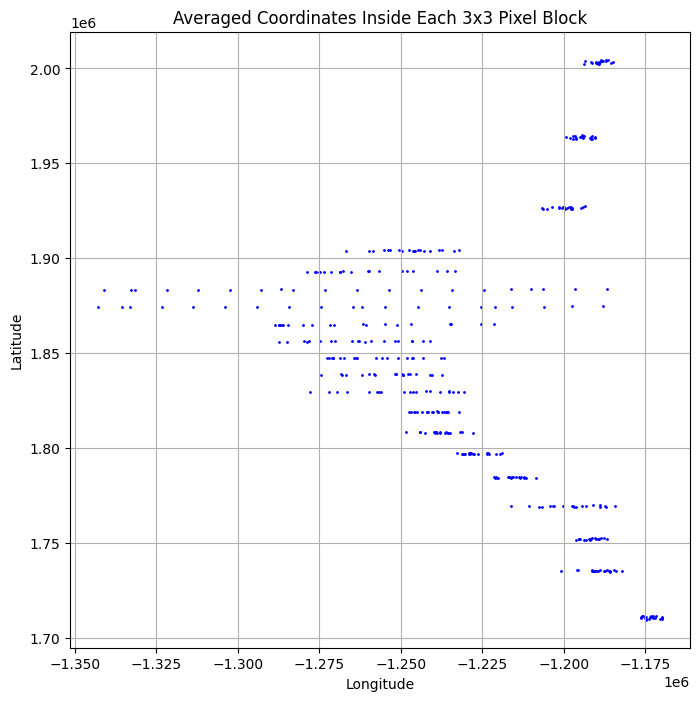

Number of averaged coordinates: 400

In [ ]:
def average_coordinates_with_value(coordinates, values, grid_size=20):
    """
    Averages coordinates in grid blocks (grid_size x grid_size) and assigns the corresponding 'Value'
    to each averaged coordinate.
    
    Args:
    - coordinates: List of tuples (x, y) representing coordinates.
    - values: List of 'Value' corresponding to the coordinates.
    - grid_size: The grid size for averaging, default is 20 (for 20x20 block).
    
    Returns:
    - A DataFrame containing the averaged coordinates and their corresponding 'Value'.
    """
    averaged_coords = []
    averaged_values = []
    
    # We assume coordinates are sorted in the same way as a raster
    num_rows = int(np.sqrt(len(coordinates)))  # Assuming square raster (rows == cols)
    
    for row in range(0, num_rows, grid_size):
        for col in range(0, num_rows, grid_size):
            # Get the coordinates within the grid block
            block_coords = []
            block_values = []
            
            for i in range(grid_size):
                for j in range(grid_size):
                    idx = (row + i) * num_rows + (col + j)  # Index in the flat list of coordinates
                    if idx < len(coordinates):  # Ensure it's within bounds
                        block_coords.append(coordinates[idx])
                        block_values.append(values[idx])
            
            # Calculate the average of x and y in the block
            if block_coords:
                avg_x = np.mean([coord[0] for coord in block_coords])
                avg_y = np.mean([coord[1] for coord in block_coords])
                
                # Find the closest original coordinate to the averaged coordinate
                tree = cKDTree(block_coords)
                dist, idx = tree.query((avg_x, avg_y))  # Get the closest original coordinate
                
                # Append the averaged coordinate and its corresponding 'Value'
                averaged_coords.append((avg_x, avg_y))
                averaged_values.append(block_values[idx])
    
    # Return the DataFrame with averaged coordinates and corresponding 'Value'
    df_averaged = pd.DataFrame(averaged_coords, columns=['longitude', 'latitude'])
    df_averaged['Value'] = averaged_values
    
    return df_averaged

In [ ]:
averaged_df = average_coordinates_with_value(dfprovaprova['coordinate'].tolist(), dfprovaprova['Value'].tolist(), grid_size=20)


In [ ]:
def transform_coordinates(x, y):
    """
    Transforms coordinates from the Sinusoidal projection to WGS 84 (Latitude/Longitude).
    
    :param x: Easting (X-coordinate) in Sinusoidal projection
    :param y: Northing (Y-coordinate) in Sinusoidal projection
    :return: A tuple containing the latitude and longitude in WGS 84
    """
    # Define the Sinusoidal projection based on the PROJ4 parameters
    src_crs = CRS.from_proj4('+proj=sinu +a=6371007.181 +b=6371007.181 +units=m')

    # Define the target CRS for WGS 84 (Latitude/Longitude)
    dst_crs = CRS("EPSG:4326")  # WGS 84 (Latitude/Longitude)

    # Create a transformer object to convert between CRS
    transformer = Transformer.from_crs(src_crs, dst_crs, always_xy=True)

    # Convert the given coordinates from Sinusoidal to Latitude/Longitude
    lon, lat = transformer.transform(x, y)

    return lat, lon

In [ ]:
averaged_df[['newlong','newlat']] = averaged_df.apply(
    lambda row: pd.Series(transform_coordinates(row['latitude'], row['longitude'])), axis=1
)

In [ ]:
import numpy as np

def euclidean_distance(coord1, coord2):
    """
    Calcola la distanza euclidea tra due coordinate (longitude, latitude).
    
    Args:
    - coord1: La prima coordinata (longitude, latitude).
    - coord2: La seconda coordinata (longitude, latitude).
    
    Returns:
    - La distanza euclidea tra le due coordinate.
    """
    return np.sqrt((coord1[0] - coord2[0])**2 + (coord1[1] - coord2[1])**2)

def add_nearest_coordinate(df, coordinate_list):
    """
    Per ogni coordinata nel dataframe, trova la coordinata più vicina dalla lista di coordinate
    e aggiungi la corrispondente coordinata nel dataframe. Ogni coordinata della lista viene
    utilizzata una sola volta.
    
    Args:
    - df: DataFrame contenente le colonne 'longitude' e 'latitude'.
    - coordinate_list: Lista di tuple 2D contenente le coordinate da cui cercare la più vicina.
    
    Returns:
    - Il DataFrame con la colonna 'coordinate' aggiunta.
    """
    # Lista che tiene traccia delle coordinate già usate
    used_coordinates = []
    
    # Funzione per trovare la coordinata più vicina per ogni riga del DataFrame
    def find_nearest(row):
        coord = (row['newlong'], row['newlat'])
        
        # Trova la coordinata più vicina usando la distanza euclidea
        min_dist = float('inf')
        nearest_coord = None
        nearest_idx = -1
        
        for idx, available_coord in enumerate(coordinate_list):
            dist = euclidean_distance(coord, available_coord)
            if dist < min_dist:
                min_dist = dist
                nearest_coord = available_coord
                nearest_idx = idx
        
        # Rimuovi la coordinata dal set di coordinate disponibili
        coordinate_list.pop(nearest_idx)
        
        return nearest_coord
    
    # Applica la funzione find_nearest a ogni riga del DataFrame
    df['coordinate'] = df.apply(find_nearest, axis=1)
    
    return df

In [ ]:
df_landcover = add_nearest_coordinate(averaged_df, averaged_coordinates)
df_landcover = df_landcover[['coordinate', 'Value']]
df_landcover = df_landcover.rename(columns={'Value': 'value2010'})


Successively, we iterated through all the yearly dataframes and merge them all into a final one : 'final_df.pkl' 

We then followed the same steps to add also the GP information, using the "MODIS_Gross_Primary_Production_GPP" folder

We finally stored the results into 'internal_data_df.pkl'